# 04 — Structural Analysis of the Annual Backbone

All metrics are computed on the simple, undirected, unweighted giant component of the annual
backbone.

1. Structural metrics: nodes, edges, density, mean/maximum/std degree, average clustering,
   transitivity, average shortest path length, diameter, degree assortativity. Path quantities are computed over the complete all-pairs distance matrix, so the diameter is exact.
2. Comparison with 10 Erdős–Rényi `G(N, M)` and 10 Barabási–Albert realizations with `m = round(M/N)`
3. Degree distribution fit with the `powerlaw` library: power law vs lognormal vs truncated power law vs exponential vs stretched exponential
4. Centrality: degree, betweenness (sampled with 500 pivots), closeness, eigenvector, plus the Pearson correlation matrix among the four

In [ ]:
# ── Repository root ───────────────────────────────────────────────────────────
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks', 'legacy') else Path.cwd()
assert (ROOT / 'data').is_dir(), f'Repository root not found from {Path.cwd()}'

## 0 - Params

In [ ]:
BACKBONE_PATH = ROOT / 'data' / 'networks' / 'annual_backbone.graphml.gz'
FIGURES_DIR   = ROOT / 'figures'
OUT_JSON      = ROOT / 'data' / 'analysis' / 'structural_metrics.json'

N_NULL      = 10      
BETWEEN_K   = 500     
RANDOM_SEED = 42

import os
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(ROOT / 'data' / 'analysis', exist_ok=True)
print('Parameters set.')

Parameters set.


## 1 - Imports

In [2]:
import json, time, warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.csgraph import shortest_path
from scipy.stats import pearsonr
import powerlaw

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style='ticks', context='paper', font_scale=1.1, rc={
    'font.family': 'serif', 'axes.linewidth': 0.7,
    'grid.linewidth': 0.4, 'grid.alpha': 0.3,
})

PAL = {'real': '#2C5F8A', 'er': '#C7563C', 'ba': '#E0A040'}

def savefig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(f'{FIGURES_DIR}/{name}.{ext}', dpi=300,
                    bbox_inches='tight', pad_inches=0.05)
    print(f'  saved {FIGURES_DIR}/{name}.png + .pdf')

print('Imports OK.')

Imports OK.


## 2 - Backbone & GCC

In [3]:
t0 = time.time()
B_raw = nx.read_graphml(BACKBONE_PATH)
try:
    B_raw = nx.relabel_nodes(B_raw, {n: int(n) for n in B_raw.nodes()})
except (ValueError, TypeError):
    pass

# Attributi dei nodi salvati prima di semplificare il grafo
NODE_NAME  = nx.get_node_attributes(B_raw, 'species_name')
NODE_TAXON = nx.get_node_attributes(B_raw, 'iconic_taxon')

# Grafo semplice non pesato per tutta l'analisi strutturale
B = nx.Graph()
B.add_nodes_from(B_raw.nodes())
B.add_edges_from(B_raw.edges())

n_components = nx.number_connected_components(B)
gcc_nodes    = max(nx.connected_components(B), key=len)
G            = B.subgraph(gcc_nodes).copy()

N = G.number_of_nodes()
M = G.number_of_edges()

print(f'Backbone completo : {B.number_of_nodes():,} nodi | {B.number_of_edges():,} archi | '
      f'{n_components} componenti')
print(f'GCC               : {N:,} nodi | {M:,} archi '
      f'({100*N/B.number_of_nodes():.2f}% dei nodi del backbone)')
print(f'Caricamento in {time.time()-t0:.1f}s')

Backbone completo : 3,023 nodi | 134,305 archi | 8 componenti
GCC               : 3,009 nodi | 134,298 archi (99.54% dei nodi del backbone)
Caricamento in 12.6s


## 3 - Metrics

In [4]:
def path_metrics(G):
    """Average shortest path, diametro esatto e distribuzione delle distanze.

    Ritorna (avg_path, diameter, counts) dove counts[d] e' il numero di coppie
    ordinate di nodi a distanza esattamente d.
    """
    A = nx.to_scipy_sparse_array(G, format='csr', weight=None)
    D = shortest_path(A, method='D', unweighted=True, directed=False)
    finite = np.isfinite(D)
    np.fill_diagonal(finite, False)          # esclude le distanze d(i,i) = 0
    vals = D[finite]
    counts = np.bincount(vals.astype(int))
    return float(vals.mean()), int(vals.max()), counts


def structural_metrics(G, with_paths=True):
    """Tutte le metriche strutturali di un grafo semplice non pesato."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    degs = np.array([d for _, d in G.degree()])

    out = {
        'nodes':          n,
        'edges':          m,
        'density':        nx.density(G),
        'avg_degree':     float(degs.mean()),
        'max_degree':     int(degs.max()),
        'std_degree':     float(degs.std()),
        'avg_clustering': nx.average_clustering(G),
        'transitivity':   nx.transitivity(G),
        'assortativity':  nx.degree_assortativity_coefficient(G),
        'n_components':   nx.number_connected_components(G),
    }
    if with_paths:
        avg_p, diam, counts = path_metrics(G)
        out['avg_path']  = avg_p
        out['diameter']  = diam
        out['path_dist'] = counts.tolist()
    return out


print('Funzioni definite.')

Funzioni definite.


## 4 - Metriche on annual network

In [5]:
t0 = time.time()
real = structural_metrics(G, with_paths=True)
print(f'Calcolate in {time.time()-t0:.1f}s')
print()

for k, v in real.items():
    if k == 'path_dist':
        continue
    print(f'  {k:<16} {v:,.4f}' if isinstance(v, float) else f'  {k:<16} {v:,}')

# Distribuzione delle lunghezze di cammino, in percentuale sulle coppie
pd_arr = np.array(real['path_dist'], dtype=float)
pd_pct = 100 * pd_arr / pd_arr.sum()
print()
print('Distribuzione delle distanze (coppie ordinate):')
for d in range(1, len(pd_pct)):
    if pd_pct[d] > 0:
        print(f'  d={d}: {pd_pct[d]:5.2f}%')

Calcolate in 94.6s

  nodes            3,009
  edges            134,298
  density          0.0297
  avg_degree       89.2642
  max_degree       1,909
  std_degree       191.3120
  avg_clustering   0.8110
  transitivity     0.2767
  assortativity    -0.4856
  n_components     1
  avg_path         2.2328
  diameter         5

Distribuzione delle distanze (coppie ordinate):
  d=1:  2.97%
  d=2: 71.44%
  d=3: 24.95%
  d=4:  0.65%
  d=5:  0.00%


## 5 — Null models: ER & BA

- **ER** `G(N, M)`: exactly the same N and M as the real network.
- **BA**: `m = round(M/N)` edges attached by each new node. The resulting number of edges is `m·N − m²` (here 45 · 3,009 − 45² = 133,380), which does not match M exactly, so the actual value is reported rather than M.

In [6]:
m_ba = max(1, int(round(M / N)))
print(f'ER: G(N={N:,}, M={M:,})')
print(f'BA: m = round(M/N) = {m_ba}  -> archi attesi ~ {m_ba*N - m_ba**2:,}')
print()

null_results = {'ER': [], 'BA': []}

for trial in range(N_NULL):
    t0 = time.time()

    G_er     = nx.gnm_random_graph(N, M, seed=RANDOM_SEED + trial)
    G_er_gcc = G_er.subgraph(max(nx.connected_components(G_er), key=len)).copy()
    m_er     = structural_metrics(G_er_gcc, with_paths=True)
    m_er['n_components'] = nx.number_connected_components(G_er)
    null_results['ER'].append(m_er)

    G_ba     = nx.barabasi_albert_graph(N, m_ba, seed=RANDOM_SEED + trial)
    G_ba_gcc = G_ba.subgraph(max(nx.connected_components(G_ba), key=len)).copy()
    m_ba_res = structural_metrics(G_ba_gcc, with_paths=True)
    m_ba_res['n_components'] = nx.number_connected_components(G_ba)
    null_results['BA'].append(m_ba_res)

    print(f'  trial {trial+1}/{N_NULL} in {time.time()-t0:5.1f}s   '
          f'ER: C={m_er["avg_clustering"]:.4f} L={m_er["avg_path"]:.3f}   '
          f'BA: C={m_ba_res["avg_clustering"]:.4f} L={m_ba_res["avg_path"]:.3f}')

print()
print('Null models completati.')

ER: G(N=3,009, M=134,298)
BA: m = round(M/N) = 45  -> archi attesi ~ 133,380

  trial 1/10 in 107.9s   ER: C=0.0299 L=2.039   BA: C=0.0754 L=2.065
  trial 2/10 in 101.7s   ER: C=0.0297 L=2.039   BA: C=0.0754 L=2.065
  trial 3/10 in  87.2s   ER: C=0.0297 L=2.039   BA: C=0.0771 L=2.062
  trial 4/10 in  93.1s   ER: C=0.0298 L=2.039   BA: C=0.0769 L=2.062
  trial 5/10 in 104.6s   ER: C=0.0298 L=2.039   BA: C=0.0760 L=2.064
  trial 6/10 in 112.9s   ER: C=0.0298 L=2.039   BA: C=0.0761 L=2.063
  trial 7/10 in 125.5s   ER: C=0.0297 L=2.039   BA: C=0.0758 L=2.064
  trial 8/10 in 127.2s   ER: C=0.0297 L=2.039   BA: C=0.0767 L=2.062
  trial 9/10 in 115.6s   ER: C=0.0296 L=2.039   BA: C=0.0761 L=2.064
  trial 10/10 in 115.9s   ER: C=0.0298 L=2.039   BA: C=0.0754 L=2.064

Null models completati.


In [ ]:
KEYS = ['nodes', 'edges', 'density', 'avg_degree', 'max_degree', 'std_degree',
        'avg_clustering', 'transitivity', 'avg_path', 'diameter',
        'assortativity', 'n_components']

def agg(model):
    out = {}
    for k in KEYS:
        vals = np.array([r[k] for r in null_results[model]], dtype=float)
        out[k] = (float(vals.mean()), float(vals.std()))
    return out

er_agg, ba_agg = agg('ER'), agg('BA')

INT_KEYS = {'nodes', 'edges', 'max_degree', 'diameter', 'n_components'}

print(f'{"Metric":<18}{"Real":>14}{"ER (mean +/- std)":>26}{"BA (mean +/- std)":>26}')
print('-' * 84)
for k in KEYS:
    r = real[k]
    em, es = er_agg[k]
    bm, bs = ba_agg[k]
    if k in INT_KEYS:
        print(f'{k:<18}{r:>14,.0f}{em:>17,.1f} +/- {es:<6.1f}{bm:>17,.1f} +/- {bs:<6.1f}')
    else:
        print(f'{k:<18}{r:>14.4f}{em:>17.4f} +/- {es:<6.4f}{bm:>17.4f} +/- {bs:<6.4f}')

print()
print(f'Clustering reale / ER = {real["avg_clustering"]/er_agg["avg_clustering"][0]:.1f}x')
print(f'Clustering reale / BA = {real["avg_clustering"]/ba_agg["avg_clustering"][0]:.1f}x')
print(f'Path reale / ER       = {real["avg_path"]/er_agg["avg_path"][0]:.2f}x')
print(f'Grado max reale / ER  = {real["max_degree"]/er_agg["max_degree"][0]:.1f}x')
print(f'Grado max reale / BA  = {real["max_degree"]/ba_agg["max_degree"][0]:.1f}x')

Metric                      Real         ER (mean +/- std)         BA (mean +/- std)
------------------------------------------------------------------------------------
nodes                      3,009          3,009.0 +/- 0.0             3,009.0 +/- 0.0   
edges                    134,298        134,298.0 +/- 0.0           133,380.0 +/- 0.0   
density                   0.0297           0.0297 +/- 0.0000           0.0295 +/- 0.0000
avg_degree               89.2642          89.2642 +/- 0.0000          88.6540 +/- 0.0000
max_degree                 1,909            124.0 +/- 2.9               608.0 +/- 32.3  
std_degree              191.3120           9.3174 +/- 0.0818          69.4207 +/- 0.4002
avg_clustering            0.8110           0.0297 +/- 0.0001           0.0761 +/- 0.0006
transitivity              0.2767           0.0297 +/- 0.0001           0.0764 +/- 0.0002
avg_path                  2.2328           2.0389 +/- 0.0001           2.0637 +/- 0.0011
diameter                     

## 6 - Small-world coefficient 

Watts-Strogatz --> small-world if `C/C_rand >> 1`
mentre `L/L_rand ~ 1` (`sigma = (C/C_rand)/(L/L_rand)` > 1)

In [8]:
C_ratio = real['avg_clustering'] / er_agg['avg_clustering'][0]
L_ratio = real['avg_path']           / er_agg['avg_path'][0]
sigma   = C_ratio / L_ratio

print(f'C / C_ER = {C_ratio:.1f}')
print(f'L / L_ER = {L_ratio:.3f}')
print(f'sigma    = {sigma:.1f}    (small-world se >> 1)')

C / C_ER = 27.3
L / L_ER = 1.095
sigma    = 24.9    (small-world se >> 1)


## 7 - Degree dist fit

In [9]:
degrees = np.array([d for _, d in G.degree()])
degrees = degrees[degrees > 0]

fit = powerlaw.Fit(degrees, discrete=True, verbose=False)

n_tail = int((degrees >= fit.power_law.xmin).sum())
print('Power-law fit:')
print(f'  alpha  = {fit.power_law.alpha:.4f}')
print(f'  x_min  = {fit.power_law.xmin:.0f}')
print(f'  sigma  = {fit.power_law.sigma:.4f}   (errore standard su alpha)')
print(f'  n_tail = {n_tail:,} nodi nella coda ({100*n_tail/len(degrees):.1f}%)')
print()

ALTS = ['lognormal', 'truncated_power_law', 'exponential', 'stretched_exponential']
print(f'{"power_law vs":<26}{"R":>10}{"p":>10}   preferita')
print('-' * 62)
fit_rows = []
for alt in ALTS:
    R, p = fit.distribution_compare('power_law', alt, normalized_ratio=True)
    if p > 0.05:
        pref = 'inconclusivo'
    else:
        pref = 'power_law' if R > 0 else alt
    print(f'{alt:<26}{R:>10.3f}{p:>10.4f}   {pref}')
    fit_rows.append({'alternative': alt, 'R': float(R), 'p': float(p), 'preferred': pref})

df_fit = pd.DataFrame(fit_rows)

Power-law fit:
  alpha  = 2.1949
  x_min  = 101
  sigma  = 0.0465   (errore standard su alpha)
  n_tail = 661 nodi nella coda (22.0%)

power_law vs                       R         p   preferita
--------------------------------------------------------------
lognormal                     -2.849    0.0044   lognormal
truncated_power_law           -4.249    0.0000   truncated_power_law
exponential                    4.993    0.0000   power_law
stretched_exponential         -2.981    0.0029   stretched_exponential


## 8 - Centralities

In [10]:
t0 = time.time()
cent = {}
cent['degree'] = dict(G.degree())
print(f'  degree OK                    {time.time()-t0:5.1f}s')
cent['betweenness'] = nx.betweenness_centrality(G, k=BETWEEN_K, seed=RANDOM_SEED,
                                                normalized=True)
print(f'  betweenness (k={BETWEEN_K}) OK      {time.time()-t0:5.1f}s')
cent['closeness'] = nx.closeness_centrality(G)
print(f'  closeness OK                 {time.time()-t0:5.1f}s')
cent['eigenvector'] = nx.eigenvector_centrality_numpy(G)
print(f'  eigenvector OK               {time.time()-t0:5.1f}s')

df_cent = pd.DataFrame(cent)
df_cent.index.name = 'taxon_id'
df_cent['species_name'] = [NODE_NAME.get(n, '?')  for n in df_cent.index]
df_cent['iconic_taxon'] = [NODE_TAXON.get(n, '?') for n in df_cent.index]

df_cent.to_csv(ROOT / 'data' / 'analysis' / 'centrality_v2.csv.gz')
print()
print(f'Salvato data/analysis/centrality_v2.csv.gz ({len(df_cent):,} righe)')

  degree OK                      0.0s
  betweenness (k=500) OK      106.7s
  closeness OK                 261.9s
  eigenvector OK               262.9s

Salvato data/analysis/centrality_v2.csv (3,009 righe)


In [ ]:
# Top-10s
for measure in ['degree', 'betweenness', 'closeness', 'eigenvector']:
    top = df_cent.nlargest(10, measure)
    print(f'Top-10 {measure}:')
    for tid, row in top.iterrows():
        val = row[measure]
        v = f'{val:,.0f}' if measure == 'degree' else f'{val:.4f}'
        print(f'  {row["species_name"]:<34s} [{row["iconic_taxon"]:<14s}] {v:>10s}')
    print()

Top-10 degree:
  Podarcis muralis                   [Reptilia      ]      1,909
  Vanessa cardui                     [Insecta       ]      1,801
  Vanessa atalanta                   [Insecta       ]      1,667
  Apis mellifera                     [Insecta       ]      1,651
  Papilio machaon                    [Insecta       ]      1,533
  Mantis religiosa                   [Insecta       ]      1,501
  Phoenicurus ochruros               [Aves          ]      1,487
  Buteo buteo                        [Aves          ]      1,453
  Pararge aegeria                    [Insecta       ]      1,439
  Turdus merula                      [Aves          ]      1,413

Top-10 betweenness:
  Podarcis muralis                   [Reptilia      ]     0.0960
  Vanessa cardui                     [Insecta       ]     0.0506
  Podarcis siculus                   [Reptilia      ]     0.0461
  Tarentola mauritanica              [Reptilia      ]     0.0418
  Mantis religiosa                   [Insecta       ] 

In [ ]:
# Pearson
MEASURES = ['degree', 'betweenness', 'closeness', 'eigenvector']
corr = df_cent[MEASURES].corr(method='pearson')

print('Correlazione di Pearson fra centralita:')
print(corr.round(3).to_string())
print()
print('Coppie (r, p):')
for i, a in enumerate(MEASURES):
    for b in MEASURES[i+1:]:
        r, p = pearsonr(df_cent[a], df_cent[b])
        print(f'  {a:<12} vs {b:<12}  r = {r:+.3f}   p = {p:.2e}')

Correlazione di Pearson fra centralita:
             degree  betweenness  closeness  eigenvector
degree        1.000        0.699      0.714        0.931
betweenness   0.699        1.000      0.394        0.494
closeness     0.714        0.394      1.000        0.815
eigenvector   0.931        0.494      0.815        1.000

Coppie (r, p):
  degree       vs betweenness   r = +0.699   p = 0.00e+00
  degree       vs closeness     r = +0.714   p = 0.00e+00
  degree       vs eigenvector   r = +0.931   p = 0.00e+00
  betweenness  vs closeness     r = +0.394   p = 2.19e-112
  betweenness  vs eigenvector   r = +0.494   p = 1.34e-184
  closeness    vs eigenvector   r = +0.815   p = 0.00e+00


## 9 - Figures

  saved figures/struct_degree_distribution.png + .pdf


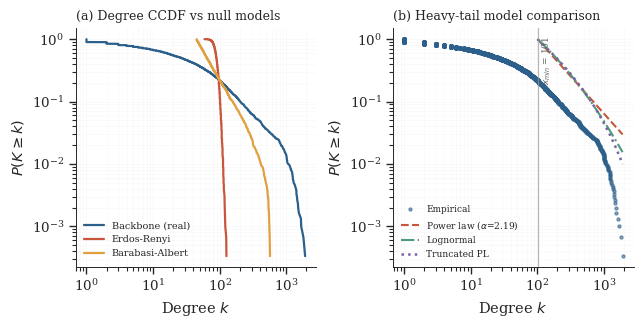

In [ ]:
# ── Fig 1: CCDF ────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.1), gridspec_kw={'wspace': 0.32})

def ccdf(vals):
    v = np.sort(np.asarray(vals))[::-1]
    return v, np.arange(1, len(v) + 1) / len(v)

deg_er = [d for _, d in nx.gnm_random_graph(N, M, seed=RANDOM_SEED).degree()]
deg_ba = [d for _, d in nx.barabasi_albert_graph(N, m_ba, seed=RANDOM_SEED).degree()]

for label, vals, color in [
    ('Backbone (real)', degrees, PAL['real']),
    ('Erdos-Renyi',     deg_er,  PAL['er']),
    ('Barabasi-Albert', deg_ba,  PAL['ba']),
]:
    x, y = ccdf(vals)
    ax1.plot(x, y, '-', color=color, lw=1.6, label=label)
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Degree $k$'); ax1.set_ylabel(r'$P(K \geq k)$')
ax1.set_title('(a) Degree CCDF vs null models', fontsize=9, loc='left')
ax1.legend(fontsize=7, frameon=False)
ax1.grid(True, which='both', alpha=0.15)

x, y = ccdf(degrees)
ax2.plot(x, y, 'o', color=PAL['real'], ms=2.2, alpha=0.55, label='Empirical', zorder=2)
fit.power_law.plot_ccdf(ax=ax2, color='#C7563C', ls='--', lw=1.5,
                        label=f'Power law ($\\alpha$={fit.power_law.alpha:.2f})')
fit.lognormal.plot_ccdf(ax=ax2, color='#4C9B7A', ls='-.', lw=1.5, label='Lognormal')
fit.truncated_power_law.plot_ccdf(ax=ax2, color='#7B61A8', ls=':', lw=1.8,
                                  label='Truncated PL')
ax2.axvline(fit.power_law.xmin, color='#999999', lw=0.9, alpha=0.7)
ax2.text(fit.power_law.xmin * 1.12, 0.45, f'$x_{{min}}$ = {fit.power_law.xmin:.0f}',
         fontsize=6.5, color='#666666', rotation=90, va='center')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Degree $k$'); ax2.set_ylabel(r'$P(K \geq k)$')
ax2.set_title('(b) Heavy-tail model comparison', fontsize=9, loc='left')
ax2.legend(fontsize=6.5, frameon=False, loc='lower left')
ax2.grid(True, which='both', alpha=0.15)

sns.despine()
fig.tight_layout()
savefig(fig, 'struct_degree_distribution')
plt.show()

  saved figures/struct_clustering_paths.png + .pdf


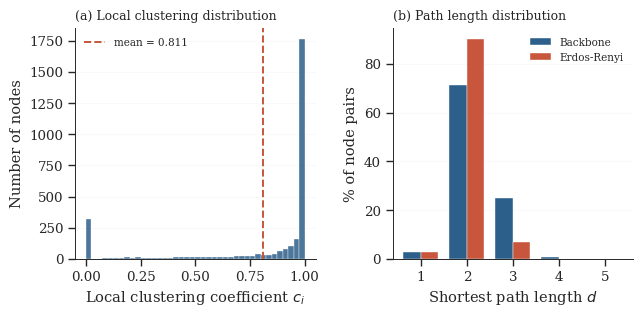

In [ ]:
# ── Fig 2: clustering & paths len ─────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.0), gridspec_kw={'wspace': 0.32})

clust_local = np.array(list(nx.clustering(G).values()))
ax1.hist(clust_local, bins=40, color=PAL['real'], alpha=0.85,
         edgecolor='white', linewidth=0.3)
ax1.axvline(clust_local.mean(), color='#C7563C', ls='--', lw=1.4,
            label=f'mean = {clust_local.mean():.3f}')
ax1.set_xlabel('Local clustering coefficient $c_i$')
ax1.set_ylabel('Number of nodes')
ax1.set_title('(a) Local clustering distribution', fontsize=9, loc='left')
ax1.legend(fontsize=7.5, frameon=False)
ax1.grid(axis='y', alpha=0.2)

er_counts = np.array(null_results['ER'][0]['path_dist'], dtype=float)
er_pct    = 100 * er_counts / er_counts.sum()
maxd      = max(len(pd_pct), len(er_pct))
xs        = np.arange(1, maxd)
w         = 0.38
ax2.bar(xs - w/2, [pd_pct[d] if d < len(pd_pct) else 0 for d in xs],
        width=w, color=PAL['real'], label='Backbone', edgecolor='white', linewidth=0.3)
ax2.bar(xs + w/2, [er_pct[d] if d < len(er_pct) else 0 for d in xs],
        width=w, color=PAL['er'], label='Erdos-Renyi', edgecolor='white', linewidth=0.3)
ax2.set_xlabel('Shortest path length $d$')
ax2.set_ylabel('% of node pairs')
ax2.set_xticks(xs)
ax2.set_title('(b) Path length distribution', fontsize=9, loc='left')
ax2.legend(fontsize=7.5, frameon=False)
ax2.grid(axis='y', alpha=0.2)

sns.despine()
fig.tight_layout()
savefig(fig, 'struct_clustering_paths')
plt.show()

  saved figures/struct_centrality.png + .pdf


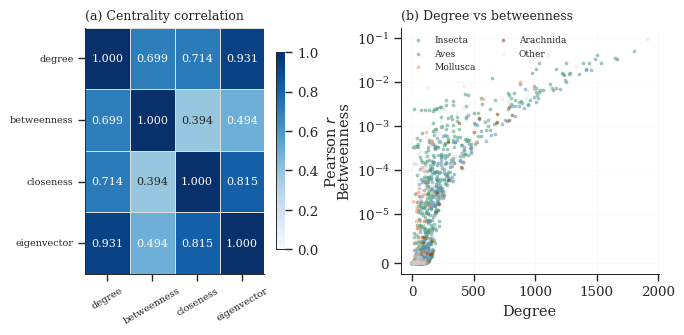

In [ ]:
# ── Fig 3: corr ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.4, 3.2),
                               gridspec_kw={'wspace': 0.38, 'width_ratios': [1, 1.15]})

sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.6, linecolor='#dddddd', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8, 'label': 'Pearson $r$'}, ax=ax1)
ax1.set_title('(a) Centrality correlation', fontsize=9, loc='left')
ax1.tick_params(axis='x', labelsize=7, rotation=30)
ax1.tick_params(axis='y', labelsize=7, rotation=0)

TAXPAL = {'Insecta': '#4C9B7A', 'Aves': '#5B8EB8', 'Mollusca': '#FF8C69',
          'Arachnida': '#8B4513', 'Actinopterygii': '#20B2AA'}
TOP_TAXA = [t for t in df_cent['iconic_taxon'].value_counts().head(5).index
            if t in TAXPAL]
for t in TOP_TAXA:
    sub = df_cent[df_cent['iconic_taxon'] == t]
    ax2.scatter(sub['degree'], sub['betweenness'], s=7, alpha=0.55,
                color=TAXPAL[t], label=t, linewidths=0)
other = df_cent[~df_cent['iconic_taxon'].isin(TOP_TAXA)]
ax2.scatter(other['degree'], other['betweenness'], s=7, alpha=0.30,
            color='#CCCCCC', label='Other', linewidths=0)
ax2.set_xlabel('Degree')
ax2.set_ylabel('Betweenness')
ax2.set_yscale('symlog', linthresh=1e-5)
ax2.set_title('(b) Degree vs betweenness', fontsize=9, loc='left')
ax2.legend(fontsize=6.5, frameon=False, ncol=2, loc='upper left')
ax2.grid(alpha=0.15)

sns.despine()
fig.tight_layout()
savefig(fig, 'struct_centrality')
plt.show()

## 10 - results

In [16]:
results = {
    'backbone': {
        'nodes':        B.number_of_nodes(),
        'edges':        B.number_of_edges(),
        'n_components': n_components,
        'gcc_nodes':    N,
        'gcc_edges':    M,
        'gcc_pct':      round(100 * N / B.number_of_nodes(), 2),
    },
    'real':    {k: real[k] for k in KEYS},
    'path_distribution_pct': {int(d): round(float(pd_pct[d]), 4)
                              for d in range(1, len(pd_pct)) if pd_pct[d] > 0},
    'null_ER': {k: {'mean': er_agg[k][0], 'std': er_agg[k][1]} for k in KEYS},
    'null_BA': {k: {'mean': ba_agg[k][0], 'std': ba_agg[k][1]} for k in KEYS},
    'small_world': {'C_ratio': C_ratio, 'L_ratio': L_ratio, 'sigma': sigma},
    'degree_fit': {
        'alpha':       float(fit.power_law.alpha),
        'xmin':        float(fit.power_law.xmin),
        'sigma':       float(fit.power_law.sigma),
        'n_tail':      n_tail,
        'comparisons': fit_rows,
    },
    'centrality_correlation': corr.round(4).to_dict(),
    'params': {'N_NULL': N_NULL, 'BETWEEN_K': BETWEEN_K, 'seed': RANDOM_SEED},
}

with open(OUT_JSON, 'w') as f:
    json.dump(results, f, indent=2, default=float)
print(f'Salvato {OUT_JSON}')

Salvato data/analysis/structural_metrics.json
